In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = pd.read_csv('../data/processed/food_waste_processed.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (214, 16)
Columns: ['country', 'combined_kg_per_capita', 'household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'confidence', 'M49_code', 'region', 'source', 'co2_household', 'co2_retail', 'co2_foodservice', 'total_co2_per_capita']


,country,combined_kg_per_capita,household_kg_per_capita,household_tonnes,retail_kg_per_capita,retail_tonnes,foodservice_kg_per_capita,foodservice_tonnes,confidence,M49_code,region,source,co2_household,co2_retail,co2_foodservice,total_co2_per_capita
0,Afghanistan,126,82,3109153,16,594982,28,1051783,Very Low Confidence,4,Southern Asia,https://www.unep.org/resources/report/unep-foo...,205.0,28.8,58.8,292.6
1,Albania,127,83,238492,16,45058,28,79651,Very Low Confidence,8,Southern Europe,https://www.unep.org/resources/report/unep-foo...,207.5,28.8,58.8,295.1
2,Algeria,135,91,3918529,16,673360,28,1190335,Very Low Confidence,12,Northern Africa,https://www.unep.org/resources/report/unep-foo...,227.5,28.8,58.8,315.1
3,Andorra,123,84,6497,13,988,26,1971,Low Confidence,20,Southern Europe,https://www.unep.org/resources/report/unep-foo...,210.0,23.4,54.6,288.0
4,Angola,144,100,3169523,16,497755,28,879908,Very Low Confidence,24,Sub-Saharan Africa,https://www.unep.org/resources/report/unep-foo...,250.0,28.8,58.8,337.6


In [3]:
# Drop columns that won't help the model
# - 'source' is just a URL link
# - 'M49_code' is just a country ID number
# - 'country' is a name, not useful for prediction
# - co2_household, co2_retail, co2_foodservice are used TO CREATE target
#   so we drop them to avoid data leakage

drop_cols = ['country', 'source', 'M49_code', 
             'co2_household', 'co2_retail', 'co2_foodservice']

df_model = df.drop(columns=drop_cols)

print("✅ Irrelevant columns dropped!")
print("Remaining columns:", df_model.columns.tolist())

✅ Irrelevant columns dropped!
Remaining columns: ['combined_kg_per_capita', 'household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'confidence', 'region', 'total_co2_per_capita']


In [4]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
num_cols = df_model.select_dtypes(include='number').columns.tolist()

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

# Check unique values in each categorical column
for col in cat_cols:
    print(f"\n{col} → {df_model[col].nunique()} unique values")
    print(df_model[col].unique())

Categorical columns: ['confidence', 'region']
Numerical columns: ['combined_kg_per_capita', 'household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'total_co2_per_capita']

confidence → 4 unique values
<StringArray>
['Very Low Confidence', 'Low Confidence', 'High Confidence',
 'Medium Confidence']
Length: 4, dtype: str

region → 17 unique values
<StringArray>
[                  'Southern Asia',                 'Southern Europe',
                 'Northern Africa',              'Sub-Saharan Africa',
 'Latin America and the Caribbean',                    'Western Asia',
       'Australia and New Zealand',                  'Western Europe',
                  'Eastern Europe',                'Northern America',
              'South-eastern Asia',                    'Eastern Asia',
                 'Northern Europe',                       'Melanesia',
                       'Polynesia',                      '

In [5]:
le = LabelEncoder()

# Encode 'confidence' and 'region'
df_model['confidence_encoded'] = le.fit_transform(df_model['confidence'])
df_model['region_encoded']     = le.fit_transform(df_model['region'])

# Save the region encoder for later use in deployment
joblib.dump(le, '../models/label_encoder.pkl')

# Drop original categorical columns
df_model = df_model.drop(columns=['confidence', 'region'])

print("✅ Categorical columns encoded!")
print(df_model.dtypes)
df_model.head()

✅ Categorical columns encoded!
combined_kg_per_capita         int64
household_kg_per_capita        int64
household_tonnes               int64
retail_kg_per_capita           int64
retail_tonnes                  int64
foodservice_kg_per_capita      int64
foodservice_tonnes             int64
total_co2_per_capita         float64
confidence_encoded             int64
region_encoded                 int64
dtype: object


,combined_kg_per_capita,household_kg_per_capita,household_tonnes,retail_kg_per_capita,retail_tonnes,foodservice_kg_per_capita,foodservice_tonnes,total_co2_per_capita,confidence_encoded,region_encoded
0,126,82,3109153,16,594982,28,1051783,292.6,3,12
1,127,83,238492,16,45058,28,79651,295.1,3,13
2,135,91,3918529,16,673360,28,1190335,315.1,3,7
3,123,84,6497,13,988,26,1971,288.0,1,13
4,144,100,3169523,16,497755,28,879908,337.6,3,14


In [6]:
X = df_model.drop(columns=['total_co2_per_capita'])
y = df_model['total_co2_per_capita']

print("Features (X):", X.columns.tolist())
print("Target (y): total_co2_per_capita")
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['combined_kg_per_capita', 'household_kg_per_capita', 'household_tonnes', 'retail_kg_per_capita', 'retail_tonnes', 'foodservice_kg_per_capita', 'foodservice_tonnes', 'confidence_encoded', 'region_encoded']
Target (y): total_co2_per_capita

X shape: (214, 9)
y shape: (214,)


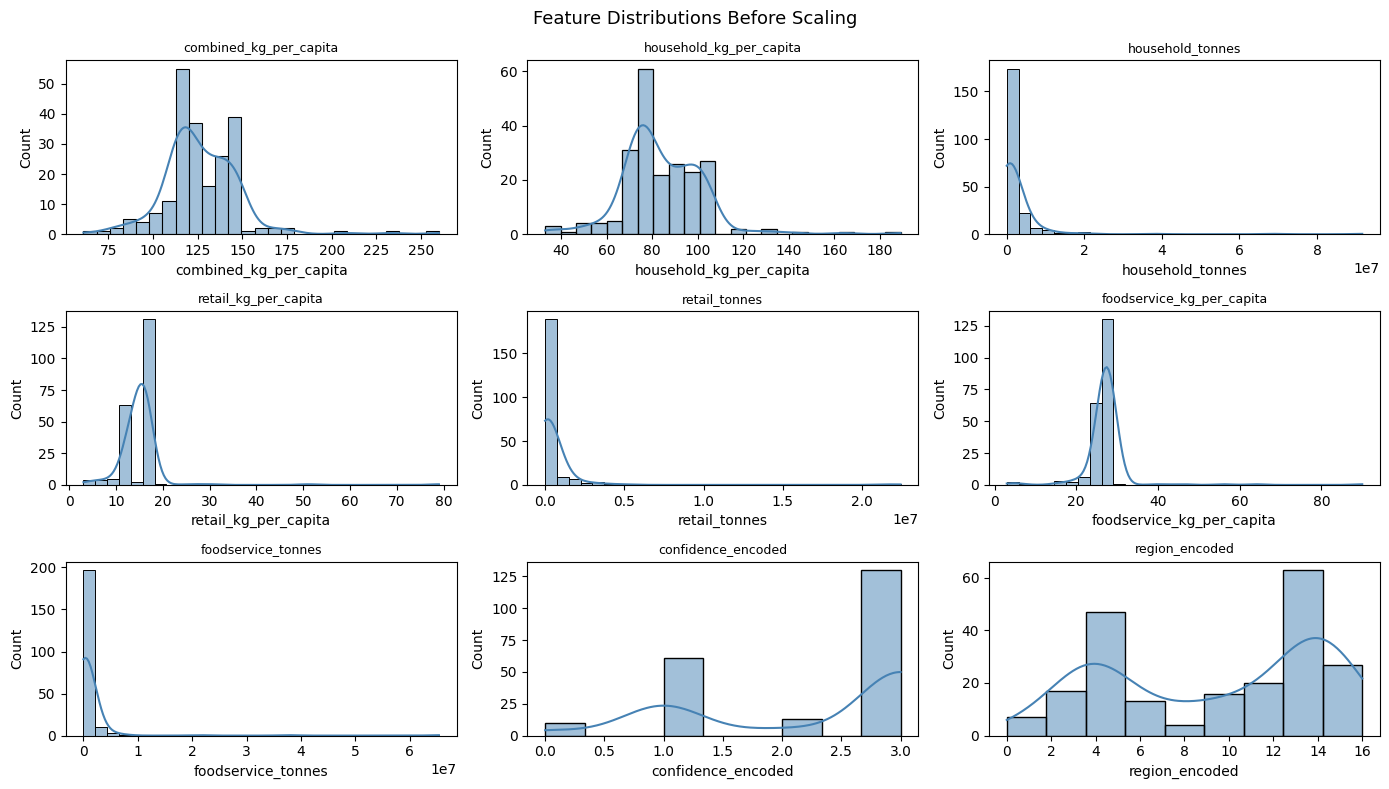

✅ Distribution plots saved!


In [7]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(X[col], kde=True, color='steelblue')
    plt.title(col, fontsize=9)
plt.suptitle('Feature Distributions Before Scaling', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/feature_distributions.png')
plt.show()
print("✅ Distribution plots saved!")

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Save scaler for deployment
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ Features scaled and scaler saved!")
print("\nBefore scaling - combined_kg_per_capita mean:", 
      round(X['combined_kg_per_capita'].mean(), 2))
print("After scaling  - combined_kg_per_capita mean:", 
      round(X_scaled['combined_kg_per_capita'].mean(), 4))

✅ Features scaled and scaler saved!

Before scaling - combined_kg_per_capita mean: 126.79
After scaling  - combined_kg_per_capita mean: 0.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42      # same split every time you run
)

print("✅ Data split complete!")
print(f"Training samples:   {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing samples:    {X_test.shape[0]}  ({X_test.shape[0]/len(X)*100:.0f}%)")

✅ Data split complete!
Training samples:   171 (80%)
Testing samples:    43  (20%)


In [10]:
# Save train and test sets
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("✅ All preprocessed data saved!")
print("\n📁 Files saved in data/processed/:")
print("   - X_train.csv")
print("   - X_test.csv")
print("   - y_train.csv")
print("   - y_test.csv")
print("   - scaler.pkl  (in models/)")
print("   - label_encoder.pkl  (in models/)")

✅ All preprocessed data saved!

📁 Files saved in data/processed/:
   - X_train.csv
   - X_test.csv
   - y_train.csv
   - y_test.csv
   - scaler.pkl  (in models/)
   - label_encoder.pkl  (in models/)


In [11]:
print("=" * 45)
print("      PREPROCESSING SUMMARY")
print("=" * 45)
print(f"Total samples          : {len(X)}")
print(f"Features used          : {X.shape[1]}")
print(f"Training samples       : {X_train.shape[0]}")
print(f"Testing samples        : {X_test.shape[0]}")
print(f"Target variable        : total_co2_per_capita")
print(f"Categorical encoded    : confidence, region")
print(f"Scaling method         : StandardScaler")
print("=" * 45)

      PREPROCESSING SUMMARY
Total samples          : 214
Features used          : 9
Training samples       : 171
Testing samples        : 43
Target variable        : total_co2_per_capita
Categorical encoded    : confidence, region
Scaling method         : StandardScaler
